In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [93]:
pilot_carriers
pilot_carriers_idx = [k + 32 for k in pilot_carriers]
pilot_carriers_idx


[11, 25, 39, 53]

In [96]:
h_data["h"]

BadZipFile: Bad magic number for file header

In [94]:
np.abs(h_data['h'][:, [11, 25, 39, 53]])

BadZipFile: Bad magic number for file header

In [2]:
def calculate_effective_snr(h_path='/tmp/h_dataset.npz', 
                            pilot_path='/tmp/pilot_dataset.npz', 
                            noise_path='/tmp/raw_noise_dataset.npz'):
    # Load the datasets
    try:
        h_data = np.load(h_path)
        pilot_data = np.load(pilot_path)
        noise_data = np.load(noise_path)
    except FileNotFoundError as e:
        print(f"Error loading datasets: {e}")
        return

    # Extract packet numbers
    pn_h = h_data['packet_num']
    pn_pilot = pilot_data['packet_num']
    pn_noise = noise_data['packet_num']
    
    # Find common packets that appear in all three datasets
    common_pns = np.intersect1d(pn_h, np.intersect1d(pn_pilot, pn_noise))
    print(f"[*] Found {len(common_pns)} common packets strictly aligned across all three datasets.")
    
    if len(common_pns) == 0:
        print("No intersecting packets found. Make sure the GNU Radio flowgraph generated all 3 files.")
        return
        
    # Convert to dictionaries for fast and strictly-aligned lookups by packet_num
    h_dict = {pn: h for pn, h in zip(pn_h, h_data['h'])}
    pilot_sig2_dict = {pn: s2 for pn, s2 in zip(pn_pilot, pilot_data['sigma2'])}
    noise_sig2_dict = {pn: s2 for pn, s2 in zip(pn_noise, noise_data['sigma2'])}
    
    # Define occupied data carriers matching your GNU Radio flowgraph
    occupied_carriers = list(range(-26, -21)) + list(range(-20, -7)) + \
                        list(range(-6, 0)) + list(range(1, 7)) + \
                        list(range(8, 21)) + list(range(22, 27))
    pilot_carriers = [-21, -7, 7, 21]
    
    # Keep only the 48 data carriers
    data_carriers = [k for k in occupied_carriers if k not in pilot_carriers]
    
    # Because your fft_vxx_1 block has shift=True, subcarrier indices in the array 
    # are shifted by N/2 (so DC 0 is at index 32)
    data_idx = [k + 32 for k in data_carriers]
    
    snr_nulls_list = []
    snr_pilots_list = []
    
    print("\n--- SNR Comparison (Last 15 Packets) ---")
    for i, pn in enumerate(sorted(common_pns)):
        h_taps = h_dict[pn]
        raw_noise_var = noise_sig2_dict[pn]
        pilot_noise_var = pilot_sig2_dict[pn]
        
        # ---------------------------------------------------------------------
        # 1. New Method: Calculate Effective Post-EQ Noise from Nulls and Taps
        # ---------------------------------------------------------------------
        # Get the power of the channel taps strictly on data subcarriers (|H_k|^2)
        h_power = np.abs(h_taps[data_idx])**2
        h_power = np.maximum(h_power, 1e-12) # Floor to avoid division by zero
        
        # Apply equalizer noise enhancement penalty mathematically: N / |H_k|^2
        post_eq_noise_per_subcarrier = raw_noise_var / h_power
        
        # Average the resulting noise across all 48 data subcarriers
        avg_post_eq_noise = np.mean(post_eq_noise_per_subcarrier)
        
        # Compute SNR (assuming Normalized Expected Signal Energy E_s = 1.0)
        snr_nulls = 10 * np.log10(1.0 / avg_post_eq_noise) if avg_post_eq_noise > 0 else -50
        snr_nulls_list.append(snr_nulls)
        
        # ---------------------------------------------------------------------
        # 2. Old Method: Calculate SNR directly from Equalized Pilots
        # ---------------------------------------------------------------------
        snr_pilots = 10 * np.log10(1.0 / pilot_noise_var) if pilot_noise_var > 0 else -50
        snr_pilots_list.append(snr_pilots)
        
        if i >= len(common_pns) - 15:
            diff = snr_nulls - snr_pilots
            print(f"Packet {pn:4d} | Nulls SNR: {snr_nulls:6.2f} dB | Pilots SNR: {snr_pilots:6.2f} dB | Diff: {diff:+5.2f} dB")
            
    # Print overall statistics
    print(f"\n--- Overall Statistics ({len(common_pns)} Packets) ---")
    print(f"Average SNR (Pre-EQ Nulls + Taps) : {np.mean(snr_nulls_list):6.2f} dB")
    print(f"Average SNR (Post-EQ Pilots)      : {np.mean(snr_pilots_list):6.2f} dB")
    
    mean_diff = np.mean(np.array(snr_nulls_list) - np.array(snr_pilots_list))
    print(f"Mean Difference                   : {mean_diff:+6.2f} dB")
    
    if mean_diff > 0:
        print("\nConclusion: The pilots method was artificially lowering your SNR estimate due to channel estimation noise.")


def calculate_effective_snr_chunked(h_path='/tmp/h_dataset.npz', 
                                    pilot_path='/tmp/pilot_dataset.npz', 
                                    noise_path='/tmp/raw_noise_dataset.npz',
                                    chunk_size=203):
    # Load the datasets
    try:
        h_data = np.load(h_path)
        pilot_data = np.load(pilot_path)
        noise_data = np.load(noise_path)
    except FileNotFoundError as e:
        print(f"Error loading datasets: {e}")
        return

    # Extract packet numbers
    pn_h = h_data['packet_num']
    pn_pilot = pilot_data['packet_num']
    pn_noise = noise_data['packet_num']
    
    # Find common packets that appear in all three datasets
    common_pns = np.intersect1d(pn_h, np.intersect1d(pn_pilot, pn_noise))
    print(f"[*] Found {len(common_pns)} common packets strictly aligned across all three datasets.")
    
    if len(common_pns) == 0:
        print("No intersecting packets found. Make sure the GNU Radio flowgraph generated all 3 files.")
        return
        
    # Convert to dictionaries for fast and strictly-aligned lookups by packet_num
    h_dict = {pn: h for pn, h in zip(pn_h, h_data['h'])}
    pilot_sig2_dict = {pn: s2 for pn, s2 in zip(pn_pilot, pilot_data['sigma2'])}
    noise_sig2_dict = {pn: s2 for pn, s2 in zip(pn_noise, noise_data['sigma2'])}
    
    # Define occupied data carriers
    occupied_carriers = list(range(-26, -21)) + list(range(-20, -7)) + \
                        list(range(-6, 0)) + list(range(1, 7)) + \
                        list(range(8, 21)) + list(range(22, 27))
    pilot_carriers = [-21, -7, 7, 21]
    
    # Keep only the 48 data carriers
    data_carriers = [k for k in occupied_carriers if k not in pilot_carriers]
    
    # Shifted indices (DC 0 is at index 32)
    data_idx = [k + 32 for k in data_carriers]
    
    linear_nulls_list = []
    linear_pilots_list = []
    
    for pn in sorted(common_pns):
        h_taps = h_dict[pn]
        raw_noise_var = noise_sig2_dict[pn]
        pilot_noise_var = pilot_sig2_dict[pn]
        
        # 1. New Method: Calculate Effective Post-EQ Noise from Nulls and Taps
        h_power = np.abs(h_taps[data_idx])**2
        h_power = np.maximum(h_power, 1e-12) # Floor to avoid division by zero
        post_eq_noise_per_subcarrier = raw_noise_var / h_power
        avg_post_eq_noise = np.mean(post_eq_noise_per_subcarrier)
        
        # Save linear SNR (E_s = 1.0)
        linear_snr_nulls = 1.0 / avg_post_eq_noise if avg_post_eq_noise > 0 else 1e-5
        linear_nulls_list.append(linear_snr_nulls)
        
        # 2. Old Method: Calculate SNR directly from Equalized Pilots
        linear_snr_pilots = 1.0 / pilot_noise_var if pilot_noise_var > 0 else 1e-5
        linear_pilots_list.append(linear_snr_pilots)

    # Compute and print means in chunks
    num_chunks = len(linear_nulls_list) // chunk_size
    print(f"\n--- SNR Averages per Image (Chunk size: {chunk_size} packets) ---")
    
    for c in range(num_chunks):
        start_idx = c * chunk_size
        end_idx = start_idx + chunk_size
        
        # Power-domain average, then convert back to dB
        mean_linear_nulls = np.mean(linear_nulls_list[start_idx:end_idx])
        mean_linear_pilots = np.mean(linear_pilots_list[start_idx:end_idx])
        
        mean_snr_nulls_db = 10 * np.log10(mean_linear_nulls)
        mean_snr_pilots_db = 10 * np.log10(mean_linear_pilots)
        
        print(f"Chunk {c+1:3d} (Packets {start_idx:5d} to {end_idx-1:5d}): Nulls SNR = {mean_snr_nulls_db:6.2f} dB | Pilots SNR = {mean_snr_pilots_db:6.2f} dB")
        
    # Process any leftover packets
    remainder = len(linear_nulls_list) % chunk_size
    if remainder > 0:
        start_idx = num_chunks * chunk_size
        end_idx = len(linear_nulls_list)
        
        mean_linear_nulls = np.mean(linear_nulls_list[start_idx:end_idx])
        mean_linear_pilots = np.mean(linear_pilots_list[start_idx:end_idx])
        
        mean_snr_nulls_db = 10 * np.log10(mean_linear_nulls)
        mean_snr_pilots_db = 10 * np.log10(mean_linear_pilots)
        
        print(f"Chunk {num_chunks+1:3d} (Packets {start_idx:5d} to {end_idx-1:5d}) [Partial: {remainder} pkts]: Nulls SNR = {mean_snr_nulls_db:6.2f} dB | Pilots SNR = {mean_snr_pilots_db:6.2f} dB")

    # Print overall statistics
    print(f"\n--- Overall Statistics ({len(common_pns)} Packets) ---")
    overall_mean_nulls = 10 * np.log10(np.mean(linear_nulls_list))
    overall_mean_pilots = 10 * np.log10(np.mean(linear_pilots_list))
    print(f"Overall Average SNR (Pre-EQ Nulls + Taps) : {overall_mean_nulls:6.2f} dB")
    print(f"Overall Average SNR (Post-EQ Pilots)      : {overall_mean_pilots:6.2f} dB")

In [3]:
calculate_effective_snr()


[*] Found 3600 common packets strictly aligned across all three datasets.

--- SNR Comparison (Last 15 Packets) ---
Packet 4037 | Nulls SNR:  21.78 dB | Pilots SNR:  -0.04 dB | Diff: +21.83 dB
Packet 4038 | Nulls SNR:  23.58 dB | Pilots SNR:  -0.13 dB | Diff: +23.71 dB
Packet 4039 | Nulls SNR:  17.80 dB | Pilots SNR:  -0.14 dB | Diff: +17.94 dB
Packet 4040 | Nulls SNR:  18.07 dB | Pilots SNR:  -0.06 dB | Diff: +18.12 dB
Packet 4041 | Nulls SNR:   6.96 dB | Pilots SNR:  -0.03 dB | Diff: +7.00 dB
Packet 4042 | Nulls SNR:  12.29 dB | Pilots SNR:  -0.14 dB | Diff: +12.43 dB
Packet 4043 | Nulls SNR:  22.87 dB | Pilots SNR:  -0.22 dB | Diff: +23.09 dB
Packet 4044 | Nulls SNR:  23.50 dB | Pilots SNR:  -0.24 dB | Diff: +23.73 dB
Packet 4045 | Nulls SNR:  15.92 dB | Pilots SNR:  -0.23 dB | Diff: +16.15 dB
Packet 4046 | Nulls SNR:  19.43 dB | Pilots SNR:  -0.00 dB | Diff: +19.44 dB
Packet 4047 | Nulls SNR:  13.34 dB | Pilots SNR:  -0.03 dB | Diff: +13.37 dB
Packet 4048 | Nulls SNR:  19.86 dB | P

In [4]:
calculate_effective_snr_chunked(chunk_size=203)


[*] Found 3600 common packets strictly aligned across all three datasets.

--- SNR Averages per Image (Chunk size: 203 packets) ---
Chunk   1 (Packets     0 to   202): Nulls SNR =  19.27 dB | Pilots SNR =  -0.02 dB
Chunk   2 (Packets   203 to   405): Nulls SNR =  17.80 dB | Pilots SNR =  -0.06 dB
Chunk   3 (Packets   406 to   608): Nulls SNR =  17.02 dB | Pilots SNR =  -0.05 dB
Chunk   4 (Packets   609 to   811): Nulls SNR =  19.92 dB | Pilots SNR =  -0.05 dB
Chunk   5 (Packets   812 to  1014): Nulls SNR =  20.71 dB | Pilots SNR =   0.01 dB
Chunk   6 (Packets  1015 to  1217): Nulls SNR =  19.64 dB | Pilots SNR =  -0.02 dB
Chunk   7 (Packets  1218 to  1420): Nulls SNR =  20.38 dB | Pilots SNR =  -0.03 dB
Chunk   8 (Packets  1421 to  1623): Nulls SNR =  20.44 dB | Pilots SNR =  -0.02 dB
Chunk   9 (Packets  1624 to  1826): Nulls SNR =  19.33 dB | Pilots SNR =  -0.01 dB
Chunk  10 (Packets  1827 to  2029): Nulls SNR =  17.44 dB | Pilots SNR =  -0.00 dB
Chunk  11 (Packets  2030 to  2232): Nu

In [5]:
# # Inner join by packet_num
# common_pn, h_idx, p_idx = np.intersect1d(
#     h_data['packet_num'], p_data['packet_num'], return_indices=True)

# h        = h_data['h'][h_idx]                   # (M, 64) complex
# mean_pil = p_data['mean_pilots'][p_idx]         # (M, 4)  complex
# sigma2   = p_data['sigma2'][p_idx]              # (M,)    float32
# snr_db   = 10 * np.log10(1.0 / sigma2)

# print(f"Merged {len(common_pn)} frames "
#       f"(h had {len(h_data['packet_num'])}, pilots had {len(p_data['packet_num'])})")

Occupied subcarriers: [-26, -25, -24, -23, -22, -20, -19, -18, -17, -16, -15, -14, -13, -12, -11, -10, -9, -8, -6, -5, -4, -3, -2, -1, 1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 22, 23, 24, 25, 26]
Occupied subcarrier indexes: [ 6  7  8  9 10 12 13 14 15 16 17 18 19 20 21 22 23 24 26 27 28 29 30 31
 33 34 35 36 37 38 40 41 42 43 44 45 46 47 48 49 50 51 52 54 55 56 57 58]


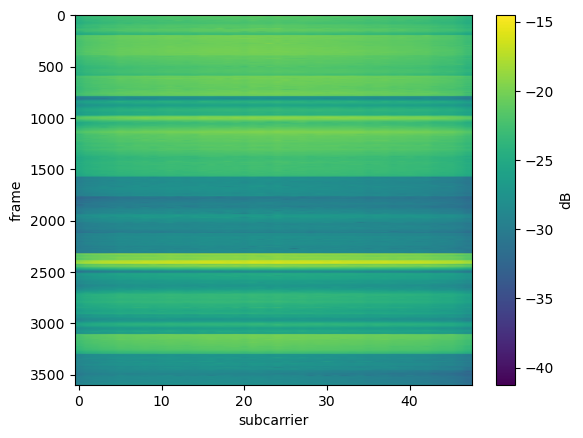

In [6]:
h_data = np.load('/tmp/h_dataset.npz')          # packet_num, h
h = h_data["h"]
n_subcarriers = h.shape[1]         # (N, 64) complex

occupied_subcarriers = list(range(-26,-21)) + list(range(-20,-7)) + list(range(-6,0)) + list(range(1,7)) + list(range(8,21)) + list(range(22,27))
occupied_subcarriers_indexes = np.array(occupied_subcarriers) + n_subcarriers//2
print("Occupied subcarriers:", occupied_subcarriers)
print("Occupied subcarrier indexes:", occupied_subcarriers_indexes)

plt.imshow(20*np.log10(np.abs(h[:, occupied_subcarriers_indexes]) + 1e-9), aspect='auto')
plt.xlabel('subcarrier'); plt.ylabel('frame'); plt.colorbar(label='dB')
plt.show()

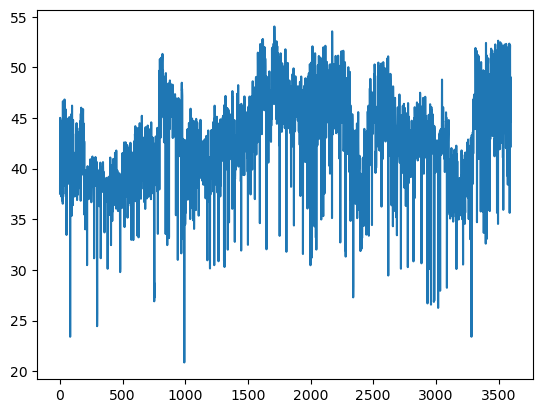

In [7]:
noise_path = '/tmp/raw_noise_dataset.npz'
noise_data = np.load(noise_path)
noise_sigma2   = noise_data['sigma2']             # (M,)    float32
noise_snr_db   = 10 * np.log10(1.0 / noise_sigma2)
plt.plot(noise_snr_db)

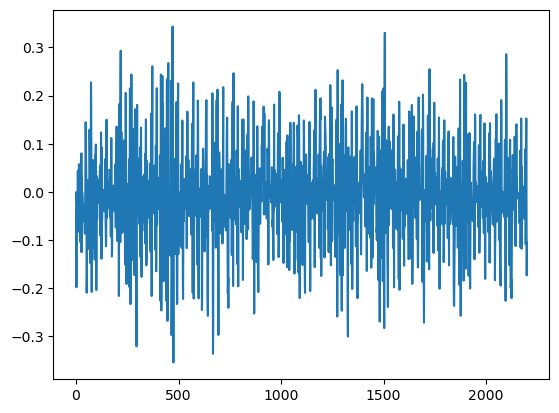

In [103]:
p_data = np.load('/tmp/pilot_dataset.npz') 
sigma2   = p_data['sigma2']             # (M,)    float32
snr_db   = 10 * np.log10(1.0 / sigma2)
plt.plot(snr_db)

In [8]:
# average snr_db per image that is every ~200 frames
avg_snr_db_per_image = []
frames_per_image = 200
for i in range(0, len(snr_db), frames_per_image):
    avg_snr_db = np.mean(snr_db[i:i+frames_per_image])
    avg_snr_db_per_image.append(avg_snr_db)

plt.plot(avg_snr_db_per_image)

NameError: name 'snr_db' is not defined

In [9]:
data_idx = [k + 32 for k in (list(range(-26, -21)) + list(range(-20, -7))
                              + list(range(-6, 0))  + list(range(1, 7))
                              + list(range(8, 21))  + list(range(22, 27)))]

H = h_data['h'][:, data_idx]                  # (n_frames, 48)
mag = np.abs(H)
print('per-frame |H_data|  min/median/max:')
print('  min   :', mag.min(axis=1).mean(),   '+/-', mag.min(axis=1).std())
print('  median:', np.median(mag, axis=1).mean())
print('  max   :', mag.max(axis=1).mean(),   '+/-', mag.max(axis=1).std())
print('per-frame |H_max| / |H_min| (dynamic range, dB):',
      20*np.log10(mag.max(axis=1) / mag.min(axis=1)).mean(), 'dB')

per-frame |H_data|  min/median/max:
  min   : 0.050332166 +/- 0.018867815
  median: 0.063819736
  max   : 0.070480116 +/- 0.025438363
per-frame |H_max| / |H_min| (dynamic range, dB): 2.9923415 dB


In [10]:
import numpy as np
p = np.load('/tmp/pilot_dataset.npz')
mean_pilots = p['mean_pilots']                         # shape (n_frames, 4)
print('mean(|mean_pilots|) per pilot:', np.abs(mean_pilots).mean(axis=0))
print('mean(angle(mean_pilots)) per pilot [rad]:', np.angle(mean_pilots).mean(axis=0))
print('std(angle(mean_pilots)) per pilot [rad]:', np.angle(mean_pilots).std(axis=0))

mean(|mean_pilots|) per pilot: [0.05706236 0.06209771 0.06256951 0.05828966]
mean(angle(mean_pilots)) per pilot [rad]: [ 0.04547696 -0.06800964  0.01608903 -0.00366465]
std(angle(mean_pilots)) per pilot [rad]: [1.8787509 1.815482  1.7936541 1.8034965]


In [11]:
# What encoder produces: should be ~unit average power per symbol
# (verify by encoding a test image locally — no GR)
import sys, os, numpy as np
sys.path.insert(0, os.path.expanduser('~/research/FINAL/github/djscc-demo/djscc_models'))
from custom_djscc.codec import Encoder
enc = Encoder(model_path='<your-checkpoint>', img_width=768, img_height=512,
              tcn=16, N=256, packet_len=960, padding_zeros=192, warmup=False)
import cv2
img = cv2.imread('/Users/marcellobullo/Downloads/noisy_img2.png')
img = cv2.resize(img, (768, 512))
sym_local = enc.encode(cv2.cvtColor(img, cv2.COLOR_BGR2RGB).tobytes())
print('local encoder avg |x|^2:', np.mean(np.abs(sym_local)**2))
print('local encoder max |x|  :', np.max(np.abs(sym_local)))

/Users/marcellobullo/miniconda3/envs/demo/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Encoder: Device=mps, 768x512, tcn=16, N=256, no CSI
codec: Checkpoint not found: <your-checkpoint>
Encoder: JIT tracing successful.
local encoder avg |x|^2: 1.9980484
local encoder max |x|  : 4.2765517


In [ ]:
np.abs(h_data['h'][:, [11, 25, 39, 53]]).mean()

np.float32(0.035525415)

In [111]:
np.abs(h_data['h'][:]).mean()

np.float32(0.02885007)

In [113]:
mean_pilots

NameError: name 'mean_pilots' is not defined

[*] Found 3600 common packets strictly aligned.

--- SNR Averages per Image (Chunk size: 203 packets) ---
Image   1 (Pkts     0 to   202): Nulls SNR =  19.27 dB | Pilots SNR =  -0.02 dB
Image   2 (Pkts   203 to   405): Nulls SNR =  17.80 dB | Pilots SNR =  -0.06 dB
Image   3 (Pkts   406 to   608): Nulls SNR =  17.02 dB | Pilots SNR =  -0.05 dB
Image   4 (Pkts   609 to   811): Nulls SNR =  19.92 dB | Pilots SNR =  -0.05 dB
Image   5 (Pkts   812 to  1014): Nulls SNR =  20.71 dB | Pilots SNR =   0.01 dB
Image   6 (Pkts  1015 to  1217): Nulls SNR =  19.64 dB | Pilots SNR =  -0.02 dB
Image   7 (Pkts  1218 to  1420): Nulls SNR =  20.38 dB | Pilots SNR =  -0.03 dB
Image   8 (Pkts  1421 to  1623): Nulls SNR =  20.44 dB | Pilots SNR =  -0.02 dB
Image   9 (Pkts  1624 to  1826): Nulls SNR =  19.33 dB | Pilots SNR =  -0.01 dB
Image  10 (Pkts  1827 to  2029): Nulls SNR =  17.44 dB | Pilots SNR =  -0.00 dB
Image  11 (Pkts  2030 to  2232): Nulls SNR =  18.87 dB | Pilots SNR =  -0.01 dB
Image  12 (Pkt

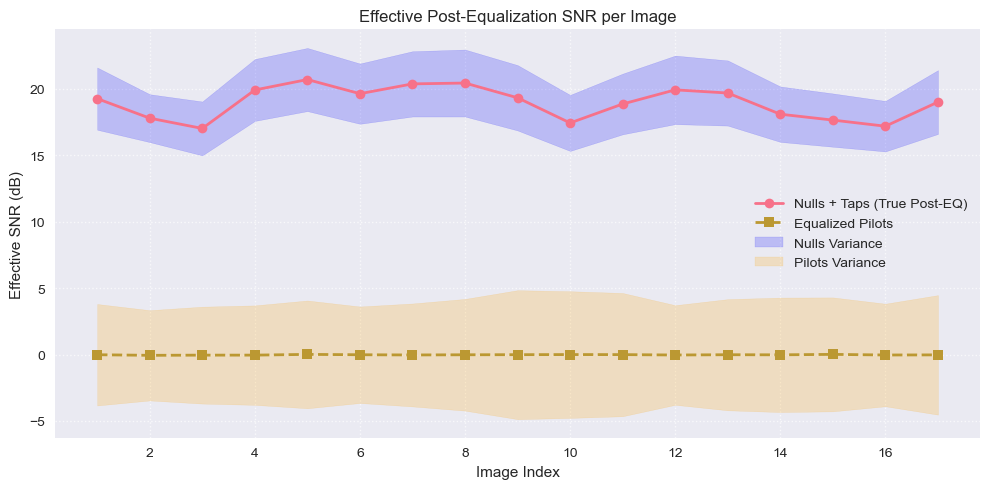

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the datasets generated by the GNU Radio flowgraph
try:
    h_data = np.load('/tmp/h_dataset.npz')
    pilot_data = np.load('/tmp/pilot_dataset.npz')
    noise_data = np.load('/tmp/raw_noise_dataset.npz')
except FileNotFoundError as e:
    print(f"Error loading datasets: {e}\nMake sure your GNU Radio flowgraph has run and generated the files.")
    raise

# Extract packet numbers
pn_h = h_data['packet_num']
pn_pilot = pilot_data['packet_num']
pn_noise = noise_data['packet_num']

# 2. Find common packets strictly aligned across all three datasets
common_pns = np.intersect1d(pn_h, np.intersect1d(pn_pilot, pn_noise))
print(f"[*] Found {len(common_pns)} common packets strictly aligned.")

# 3. Create dictionaries for fast, aligned lookups
h_dict = {pn: h for pn, h in zip(pn_h, h_data['h'])}
pilot_sig2_dict = {pn: s2 for pn, s2 in zip(pn_pilot, pilot_data['sigma2'])}
noise_sig2_dict = {pn: s2 for pn, s2 in zip(pn_noise, noise_data['sigma2'])}

# 4. Define OFDM parameters matching your GNU Radio flowgraph
occupied_carriers = list(range(-26, -21)) + list(range(-20, -7)) + \
                    list(range(-6, 0)) + list(range(1, 7)) + \
                    list(range(8, 21)) + list(range(22, 27))
pilot_carriers = [-21, -7, 7, 21]

# Keep only the 48 data carriers
data_carriers = [k for k in occupied_carriers if k not in pilot_carriers]

# Shifted indices (since shift=True in FFT, DC is at index 32)
data_idx = [k + 32 for k in data_carriers]

linear_nulls_list = []
linear_pilots_list = []
packet_numbers = sorted(common_pns)

# 5. Compute SNR for each packet
for pn in packet_numbers:
    h_taps = h_dict[pn]
    raw_noise_var = noise_sig2_dict[pn]
    pilot_noise_var = pilot_sig2_dict[pn]
    
    # ---------------------------------------------------------------------
    # NEW METHOD: Calculate Effective Post-EQ Noise from Nulls and Taps
    # ---------------------------------------------------------------------
    # Power of the channel taps strictly on data subcarriers (|H_k|^2)
    h_power = np.abs(h_taps[data_idx])**2
    h_power = np.maximum(h_power, 1e-12) # Floor to avoid division by zero
    
    # Apply Zero-Forcing noise enhancement penalty mathematically: N / |H_k|^2
    post_eq_noise_per_subcarrier = raw_noise_var / h_power
    avg_post_eq_noise = np.mean(post_eq_noise_per_subcarrier)
    
    # Save linear SNR (Assuming normalized expected signal energy E_s = 1.0)
    linear_snr_nulls = 1.0 / avg_post_eq_noise if avg_post_eq_noise > 0 else 1e-5
    linear_nulls_list.append(linear_snr_nulls)
    
    # ---------------------------------------------------------------------
    # OLD METHOD: Calculate SNR directly from Equalized Pilots
    # ---------------------------------------------------------------------
    linear_snr_pilots = 1.0 / pilot_noise_var if pilot_noise_var > 0 else 1e-5
    linear_pilots_list.append(linear_snr_pilots)

# 6. Group by Images (Chunks of 203 packets)
chunk_size = 203
num_chunks = len(linear_nulls_list) // chunk_size

chunk_snr_nulls = []
chunk_snr_pilots = []

chunk_snr_nulls_std = []
chunk_snr_pilots_std = []

print(f"\n--- SNR Averages per Image (Chunk size: {chunk_size} packets) ---")
for c in range(num_chunks):
    start_idx = c * chunk_size
    end_idx = start_idx + chunk_size
    
    # Average in the linear power domain, then convert to dB
    mean_linear_nulls = np.mean(linear_nulls_list[start_idx:end_idx])
    std_linear_nulls = np.std(linear_nulls_list[start_idx:end_idx])
    
    mean_linear_pilots = np.mean(linear_pilots_list[start_idx:end_idx])
    std_linear_pilots = np.var(linear_pilots_list[start_idx:end_idx])
    
    snr_nulls_db = 10 * np.log10(mean_linear_nulls)
    snr_nulls_db_std = 10 * np.log10(std_linear_nulls)

    snr_pilots_db = 10 * np.log10(mean_linear_pilots)
    snr_pilots_db_std = 10 * np.log10(std_linear_pilots)
    
    chunk_snr_nulls.append(snr_nulls_db)
    chunk_snr_pilots.append(snr_pilots_db)
    
    chunk_snr_nulls_std.append(snr_nulls_db_std)
    chunk_snr_pilots_std.append(snr_pilots_db_std)

    print(f"Image {c+1:3d} (Pkts {start_idx:5d} to {end_idx-1:5d}): "
          f"Nulls SNR = {snr_nulls_db:6.2f} dB | Pilots SNR = {snr_pilots_db:6.2f} dB")

# Overall means in dB 
overall_nulls_db = 10 * np.log10(np.mean(linear_nulls_list))
overall_pilots_db = 10 * np.log10(np.mean(linear_pilots_list))
print(f"\n--- Overall Statistics ---")
print(f"Overall Nulls SNR : {overall_nulls_db:6.2f} dB")
print(f"Overall Pilots SNR: {overall_pilots_db:6.2f} dB")

# 7. Visualization
if num_chunks > 0:
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, num_chunks + 1), chunk_snr_nulls, marker='o', linestyle='-', linewidth=2, label='Nulls + Taps (True Post-EQ)')
    plt.plot(range(1, num_chunks + 1), chunk_snr_pilots, marker='s', linestyle='--', linewidth=2, label='Equalized Pilots')

    plt.fill_between(range(1, num_chunks + 1), 
                     np.array(chunk_snr_nulls) - (1.96/np.sqrt(chunk_size))*np.array(chunk_snr_nulls_std),
                     np.array(chunk_snr_nulls) + (1.96/np.sqrt(chunk_size))*np.array(chunk_snr_nulls_std),
                     color='blue', alpha=0.2, label='Nulls Variance')
    plt.fill_between(range(1, num_chunks + 1), 
                     np.array(chunk_snr_pilots) - (1.96/np.sqrt(chunk_size))*np.array(chunk_snr_pilots_std),
                     np.array(chunk_snr_pilots) + (1.96/np.sqrt(chunk_size))*np.array(chunk_snr_pilots_std),
                     color='orange', alpha=0.2, label='Pilots Variance')
    
    plt.title('Effective Post-Equalization SNR per Image')
    plt.xlabel('Image Index')
    plt.ylabel('Effective SNR (dB)')
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [ ]:
h = np.load("/tmp/h_dataset.npy") 
n_subcarriers = h.shape[1]         # (N, 64) complex
print(h.shape)

# look at how |h| evolves over frames


occupied_subcarriers = list(range(-26,-21)) + list(range(-20,-7)) + list(range(-6,0)) + list(range(1,7)) + list(range(8,21)) + list(range(22,27))
occupied_subcarriers_indexes = np.array(occupied_subcarriers) + n_subcarriers//2
print("Occupied subcarriers:", occupied_subcarriers)
print("Occupied subcarrier indexes:", occupied_subcarriers_indexes)

plt.imshow(20*np.log10(np.abs(h[:, occupied_subcarriers_indexes]) + 1e-9), aspect='auto')
plt.xlabel('subcarrier'); plt.ylabel('frame'); plt.colorbar(label='dB')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/tmp/h_dataset.npy'

In [28]:
h.dtype

dtype('complex64')

(3546, 64)
Occupied subcarriers: [-26, -25, -24, -23, -22, -20, -19, -18, -17, -16, -15, -14, -13, -12, -11, -10, -9, -8, -6, -5, -4, -3, -2, -1, 1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 22, 23, 24, 25, 26]
Occupied subcarrier indexes: [ 6  7  8  9 10 12 13 14 15 16 17 18 19 20 21 22 23 24 26 27 28 29 30 31
 33 34 35 36 37 38 40 41 42 43 44 45 46 47 48 49 50 51 52 54 55 56 57 58]


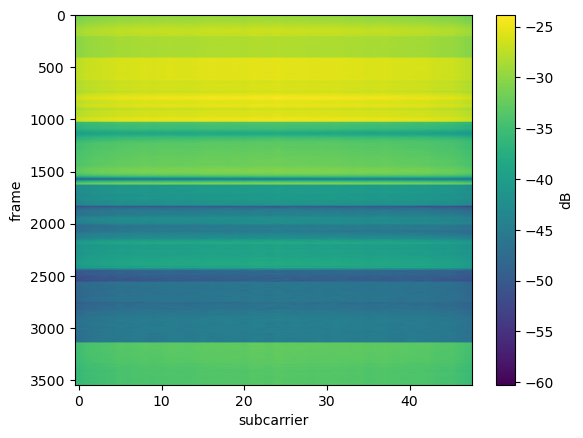

Estimated SNR per frame: [0.00519116 0.00627135 0.0063527  ... 0.00144013 0.00131981 0.00129604]


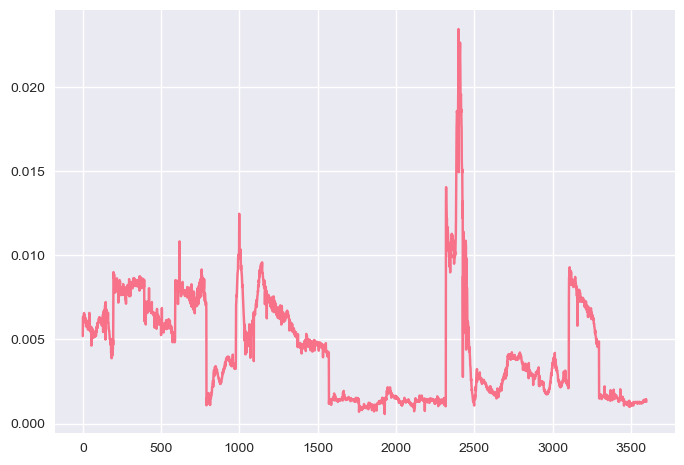

In [13]:
pilot_subcarriers = [-21, -7, 7, 21]
pilot_subcarriers_indexes = np.array(pilot_subcarriers) + n_subcarriers//2
pilots_symbols = [1, 1, 1, -1]
pilots_symbols_eq = pilots_symbols / np.abs(h[:, pilot_subcarriers_indexes])
noise_power_estimate = np.mean(np.abs(pilots_symbols_eq - h[:, pilot_subcarriers_indexes])**2, axis=1)
SNR = 1 / noise_power_estimate
print("Estimated SNR per frame:", SNR)
plt.plot(SNR)

In [100]:
h[0,:]

array([ 0.        +0.j        ,  0.        +0.j        ,
        0.        +0.j        ,  0.        +0.j        ,
        0.        +0.j        ,  0.        +0.j        ,
       -0.01969074+0.02234484j, -0.00098064+0.03002578j,
        0.01792524+0.02325795j,  0.02467017+0.0060831j ,
        0.03098707-0.01307285j,  0.01133479-0.02288477j,
       -0.01177658-0.03187285j, -0.02785601-0.0122055j ,
       -0.0252868 +0.01005435j, -0.02137893+0.02199292j,
        0.00211   +0.03490541j,  0.0256167 +0.01794234j,
        0.03061983-0.00695992j,  0.01831548-0.02751236j,
       -0.00290555-0.03387567j, -0.01947165-0.02472674j,
       -0.0319698 -0.00555668j, -0.02323675+0.01913673j,
       -0.00245658+0.03156867j,  0.01956725+0.02636323j,
        0.0296557 +0.00823077j,  0.03049707-0.00410357j,
        0.02154882-0.03128233j, -0.00400833-0.02947419j,
       -0.02650007-0.02350989j, -0.03296086+0.00211399j,
        0.        +0.j        , -0.00235208+0.02915508j,
        0.0185858 +0.02934464j,

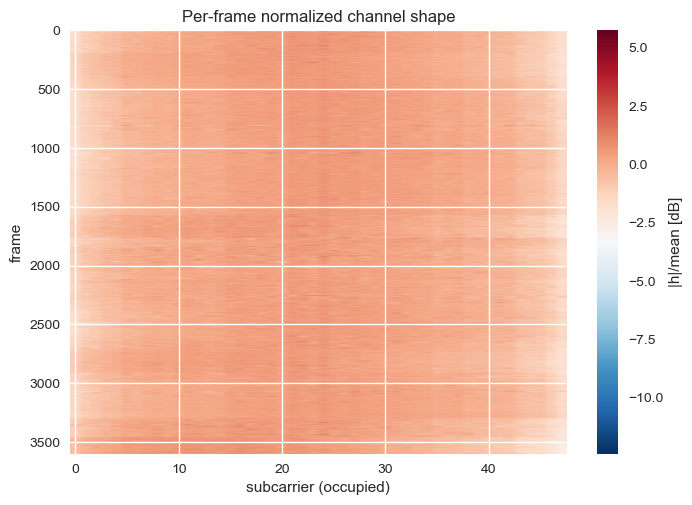

In [14]:
mag = np.abs(h[:, occupied_subcarriers_indexes])
mag_norm = mag / mag.mean(axis=1, keepdims=True)   # divide each frame by its own mean
db = 20*np.log10(mag_norm + 1e-9)
plt.imshow(db, aspect='auto', cmap='RdBu_r')
plt.xlabel('subcarrier (occupied)'); plt.ylabel('frame')
plt.colorbar(label='|h|/mean [dB]')
plt.title('Per-frame normalized channel shape')
plt.show()

In [93]:
np.abs(H)[0]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.02978283, 0.02936404, 0.02540908, 0.0336318 , 0.02553801,
       0.03397892, 0.03041269, 0.02721235, 0.03067161, 0.03496913,
       0.03127527, 0.03140087, 0.03305127, 0.03400004, 0.03244912,
       0.03010251, 0.03166411, 0.03283135, 0.03077672, 0.03129943,
       0.03816232, 0.03250568, 0.02639056, 0.03509473, 0.03290171,
       0.03245312, 0.02947742, 0.02875289, 0.03303685, 0.03417166,
       0.03039145, 0.02680125, 0.02999876, 0.03073185, 0.02900923,
       0.03134355, 0.02557434, 0.02350504, 0.        , 0.        ,
       0.        , 0.        , 0.        ], dtype=float32)

In [94]:
H[0]

array([ 0.        +0.j        ,  0.        +0.j        ,
        0.        +0.j        ,  0.        +0.j        ,
        0.        +0.j        , -0.01969074+0.02234484j,
        0.01792524+0.02325795j,  0.02467017+0.0060831j ,
        0.03098707-0.01307285j,  0.01133479-0.02288477j,
       -0.01177658-0.03187285j, -0.02785601-0.0122055j ,
       -0.0252868 +0.01005435j, -0.02137893+0.02199292j,
        0.00211   +0.03490541j,  0.0256167 +0.01794234j,
        0.03061983-0.00695992j,  0.01831548-0.02751236j,
       -0.00290555-0.03387567j, -0.0319698 -0.00555668j,
       -0.02323675+0.01913673j, -0.00245658+0.03156867j,
        0.01956725+0.02636323j,  0.0296557 +0.00823077j,
       -0.00707071-0.03049032j, -0.03573255-0.01339953j,
       -0.03008266+0.01231473j, -0.0116302 +0.02368966j,
        0.00312201+0.03495559j,  0.03140859-0.00979911j,
        0.01615731-0.0281451j , -0.00405064-0.02919779j,
       -0.01792904-0.0224784j , -0.03226719-0.00708959j,
       -0.02649939+0.0215751j ,

In [15]:
occ = sorted(set(list(range(-26,-21)) + list(range(-20,-7)) + list(range(-6,0))
                 + list(range(1,7)) + list(range(8,21)) + list(range(22,27))))
occ

[-26,
 -25,
 -24,
 -23,
 -22,
 -20,
 -19,
 -18,
 -17,
 -16,
 -15,
 -14,
 -13,
 -12,
 -11,
 -10,
 -9,
 -8,
 -6,
 -5,
 -4,
 -3,
 -2,
 -1,
 1,
 2,
 3,
 4,
 5,
 6,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 22,
 23,
 24,
 25,
 26]